replace /content/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
N
A
n
Memproses Audio dan Mengekstrak Fitur MFCC...

Memulai Training Multi-Task (50 Epochs)...
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 2.6499 - prediksi_emosi_accuracy: 0.1936 - prediksi_emosi_loss: 2.0117 - prediksi_intensitas_accuracy: 0.6523 - prediksi_intensitas_loss: 0.6382 - val_loss: 2.5636 - val_prediksi_emosi_accuracy: 0.2483 - val_prediksi_emosi_loss: 1.9390 - val_prediksi_intensitas_accuracy: 0.6597 - val_prediksi_intensitas_loss: 0.6246
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.5006 - prediksi_emosi_accuracy: 0.2587 - prediksi_emosi_loss: 1.8967 - prediksi_intensitas_accuracy: 0.6914 - prediksi_intensitas_loss: 0.6039 - val_loss: 2.4126 - val_prediksi_emosi_accuracy: 0.3194 - val_prediksi_emosi_loss: 1.8456 - val_prediksi_intensitas_accuracy: 0.7361 - val_prediksi_intensitas_loss: 0.5670
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


Berhasil disimpan!


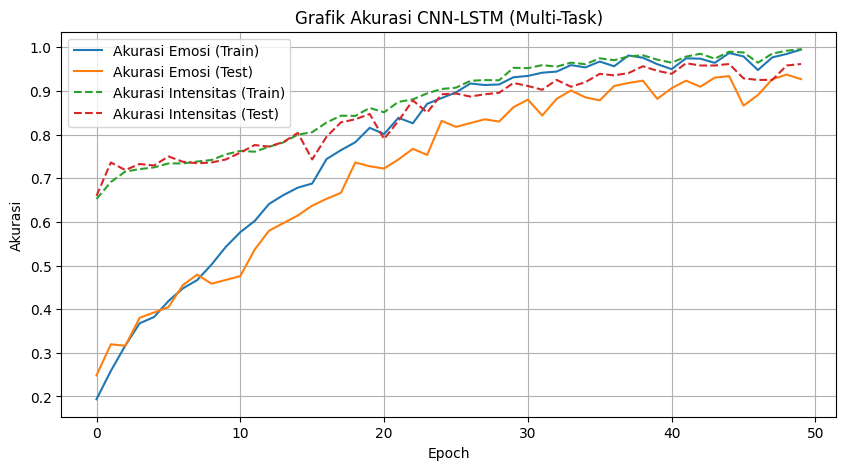

In [ ]:
# 1. Ekstrak Dataset
!unzip -q /content/RAVDESS.zip -d /content/RAVDESS

# 2. Import Library & Persiapan
import os
import librosa
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

dataset_path = '/content/RAVDESS'

emotion_dict = {
    '01': 'Netral', '02': 'Santai', '03': 'Senang', '04': 'Sedih',
    '05': 'Marah', '06': 'Takut', '07': 'Jijik', '08': 'Terkejut'
}
intensity_dict = {'01': 'Normal', '02': 'Kuat'}

X, y_emo, y_int = [], [], []
print("Memproses Audio dan Mengekstrak Fitur MFCC...")

for subdir, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            if len(parts) >= 4:
                emotion_code = parts[2]
                intensity_code = parts[3]

                if emotion_code in emotion_dict:
                    file_path = os.path.join(subdir, file)
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                    mfccs = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)
                    mfccs_mean = np.mean(mfccs.T, axis=0)

                    X.append(mfccs_mean)
                    y_emo.append(emotion_dict[emotion_code])
                    y_int.append(intensity_dict[intensity_code])

X = np.array(X)
y_emo = np.array(y_emo)
y_int = np.array(y_int)

# 3. Label Encoder & Split Data
le_emo = LabelEncoder()
le_int = LabelEncoder()

y_emo_cat = to_categorical(le_emo.fit_transform(y_emo))
y_int_cat = to_categorical(le_int.fit_transform(y_int))

X_train, X_test, y_emo_train, y_emo_test, y_int_train, y_int_test = train_test_split(
    X, y_emo_cat, y_int_cat, test_size=0.2, random_state=42
)
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# 4. Arsitektur Multi-Task
input_layer = Input(shape=(40, 1))
x = Conv1D(64, kernel_size=3, activation='relu')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, kernel_size=3, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(64, return_sequences=False)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

output_emosi = Dense(8, activation='softmax', name='prediksi_emosi')(x)
output_intensitas = Dense(2, activation='softmax', name='prediksi_intensitas')(x)

model = Model(inputs=input_layer, outputs=[output_emosi, output_intensitas])
model.compile(
    optimizer='adam',
    loss={'prediksi_emosi': 'categorical_crossentropy', 'prediksi_intensitas': 'categorical_crossentropy'},
    metrics={'prediksi_emosi': 'accuracy', 'prediksi_intensitas': 'accuracy'}
)

print("\nMemulai Training Multi-Task (50 Epochs)...")
history = model.fit(
    X_train, {'prediksi_emosi': y_emo_train, 'prediksi_intensitas': y_int_train},
    validation_data=(X_test, {'prediksi_emosi': y_emo_test, 'prediksi_intensitas': y_int_test}),
    epochs=50, batch_size=32, verbose=1
)

# 5. Simpan File Model & Plot Grafik
model.save('model_multitask.h5')
with open('le_emosi.pkl', 'wb') as f:
    pickle.dump(le_emo, f)
with open('le_intensitas.pkl', 'wb') as f:
    pickle.dump(le_int, f)

print("\nBerhasil disimpan!")

plt.figure(figsize=(10, 5))
plt.plot(history.history['prediksi_emosi_accuracy'], label='Akurasi Emosi (Train)')
plt.plot(history.history['val_prediksi_emosi_accuracy'], label='Akurasi Emosi (Test)')
plt.plot(history.history['prediksi_intensitas_accuracy'], label='Akurasi Intensitas (Train)', linestyle='--')
plt.plot(history.history['val_prediksi_intensitas_accuracy'], label='Akurasi Intensitas (Test)', linestyle='--')
plt.title('Grafik Akurasi CNN-LSTM (Multi-Task)')
plt.ylabel('Akurasi')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()